# Configuración básica (no tocar)

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [79]:
x = Variable()

# Implementación de métodos

In [80]:
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000) -> tuple:
    """
    Método de bisección para encontrar ceros de la derivada (puntos críticos).

    Usa el teorema de Bolzano aplicado a la derivada en el intervalo [a, b].
    Divide el intervalo en mitades hasta que la derivada en el punto medio
    esté dentro de la tolerancia o hasta que el intervalo sea suficientemente pequeño.

    Parámetros:
    ----------
    f : Function
        Función original a optimizar.
    a : float
        Extremo izquierdo del intervalo de búsqueda.
    b : float
        Extremo derecho del intervalo de búsqueda.
    tol : float, optional
        Tolerancia absoluta para el valor de la derivada o el ancho del intervalo.
    max_iter : int, optional
        Número máximo de iteraciones.

    Retorna:
    -------
    tuple:
        x aproximado del cero de la derivada, número de iteraciones y lista de historial.

    Raises:
    ------
    ValueError:
        Si la derivada no cambia de signo en el intervalo inicial.
    """
    # Derivada de la función original
    df = f.derivative()

    fa = df.eval(a)
    fb = df.eval(b)

    # Verificación de Bolzano en la derivada
    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en el intervalo dado")

    history = []

    for step in range(1, max_iter + 1):
        xn = (a + b) / 2
        history.append(xn)
        fxn = df.eval(xn)

        # Criterio de convergencia: valor de la derivada cercano a cero o intervalo pequeño
        if abs(fxn) < tol or abs(b - a) < tol:
            return xn, step, history

        # Elige el subintervalo donde la derivada cambia de signo
        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn

    return xn, max_iter, history


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000) -> tuple:
    """
    Método de Newton-Raphson para encontrar ceros de la derivada (puntos críticos).

    Usa primera y segunda derivada para actualizar la aproximación con pasos
    de Newton. El método converge rápidamente cuando la segunda derivada no es cero.

    Parámetros:
    ----------
    f : Function
        Función original a optimizar.
    x0 : float
        Punto inicial para la iteración.
    tol : float, optional
        Tolerancia en el cambio de la aproximación entre iteraciones.
    max_iter : int, optional
        Número máximo de iteraciones.

    Retorna:
    -------
    tuple:
        x aproximado del cero de la derivada, número de iteraciones y lista de historial.

    Raises:
    ------
    ValueError:
        Si la segunda derivada en la iteración es cercana a cero.
    """
    df = f.derivative()
    ddf = df.derivative()

    xn = x0
    history = [xn]

    for step in range(1, max_iter + 1):
        dfxn = df.eval(xn)
        ddfxn = ddf.eval(xn)

        # Evita división por cero o pasos numéricamente inestables
        if abs(ddfxn) < 1e-12:
            raise ValueError("La segunda derivada es muy cercana a cero")

        x_next = xn - dfxn / ddfxn

        # Criterio de convergencia en el desplazamiento de x
        if abs(x_next - xn) < tol:
            history.append(x_next)
            return x_next, step, history

        xn = x_next
        history.append(xn)

    return xn, max_iter, history


def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000) -> tuple:
    """
    Método de descenso por gradiente para encontrar puntos críticos.

    En cada iteración, se da un paso en la dirección opuesta al gradiente
    con tamaño de paso lr (learning rate).

    Parámetros:
    ----------
    f : Function
        Función original a optimizar.
    x0 : float
        Punto inicial para la iteración.
    lr : float
        Learning rate, tamaño de paso del algoritmo.
    tol : float, optional
        Tolerancia en el cambio de la aproximación entre iteraciones.
    max_iter : int, optional
        Número máximo de iteraciones.

    Retorna:
    -------
    tuple:
        x aproximado del punto crítico, número de iteraciones y lista de historial.
    """
    df = f.derivative()

    xn = x0
    history = [xn]

    for step in range(1, max_iter + 1):
        gradiente = df.eval(xn)
        x_next = xn - lr * gradiente

        # Criterio de convergencia basado en la variación de x
        if abs(x_next - xn) < tol:
            history.append(x_next)
            return x_next, step, history

        xn = x_next
        history.append(xn)

    return xn, max_iter, history


def graficar_recorrido(f, history, titulo, x_min=-3, x_max=5) -> None:
    """
    Visualiza el recorrido de un algoritmo de optimización sobre la función.

    Dibuja la función original y los puntos visitados por el algoritmo,
    coloreando cada paso según su número de iteración.

    Parámetros:
    ----------
    f : Function
        Función a graficar.
    history : list
        Lista de valores x visitados por el algoritmo.
    titulo : str
        Título del gráfico.
    x_min : float, optional
        Límite izquierdo del eje x.
    x_max : float, optional
        Límite derecho del eje x.
    """
    # Genera puntos para mostrar la curva completa de la función
    lp = np.linspace(x_min, x_max, 300)

    plt.figure(figsize=(10, 6))
    plt.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))), label="f(x)")

    history_x = np.array(history)
    history_y = np.array(list(map(lambda v: f.eval(v), history_x)))

    # Grafica el historial de iteraciones con codificación de color
    scatter = plt.scatter(
        history_x,
        history_y,
        c=range(len(history)),
        cmap="viridis",
        s=80,
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
        label="Iteraciones",
    )

    plt.colorbar(scatter, label="Número de iteración")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



### Prueba de métodos

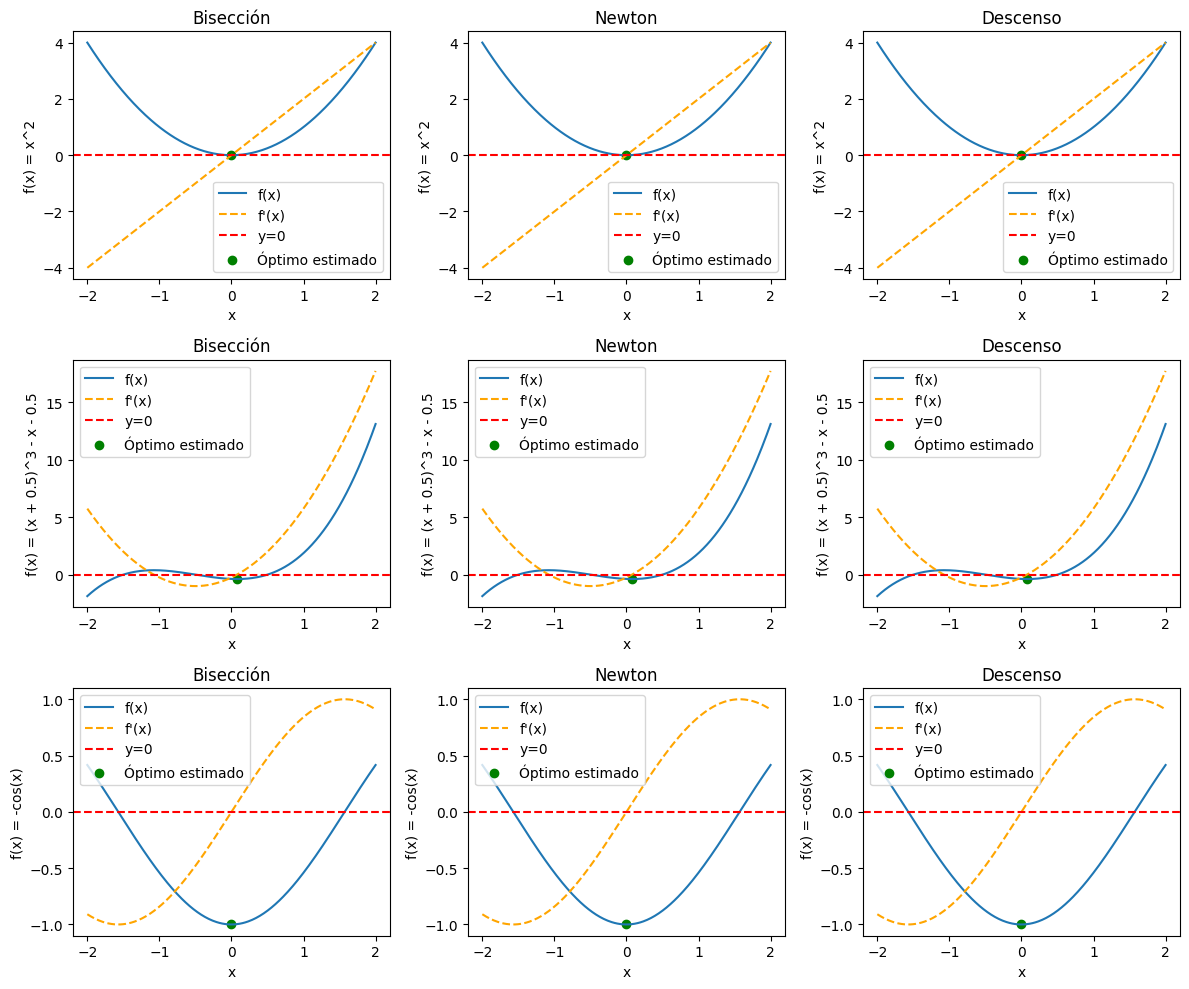

In [81]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step, _ = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

In [82]:
# Resultados numéricos de la verificación
print("f1 = x²")
print("Bisección:", biseccion(f1, -1, 1))
print("Newton:", newton(f1, 1))
print("Gradiente:", descenso_gradiente(f1, 1, lr=0.01))

print()

print("f2")
print("Bisección:", biseccion(f2, -1, 1))
print("Newton:", newton(f2, 1))
print("Gradiente:", descenso_gradiente(f2, 1, lr=0.01))

print()

print("f3")
print("Bisección:", biseccion(f3, -1, 1))
print("Newton:", newton(f3, 1))
print("Gradiente:", descenso_gradiente(f3, 1, lr=0.01))

f1 = x²
Bisección: (0.0, 1, [0.0])
Newton: (0.0, 2, [1, 0.0, 0.0])
Gradiente: (4.8220225910828e-05, 492, [1, 0.98, 0.9604, 0.941192, 0.92236816, 0.9039207968, 0.885842380864, 0.86812553324672, 0.8507630225817856, 0.8337477621301499, 0.8170728068875469, 0.800731350749796, 0.7847167237348001, 0.769022389260104, 0.7536419414749019, 0.7385691026454039, 0.7237977205924958, 0.7093217661806459, 0.6951353308570329, 0.6812326242398923, 0.6676079717550945, 0.6542558123199925, 0.6411706960735927, 0.6283472821521208, 0.6157803365090784, 0.6034647297788968, 0.5913954351833188, 0.5795675264796525, 0.5679761759500594, 0.5566166524310583, 0.5454843193824371, 0.5345746329947884, 0.5238831403348926, 0.5134054775281948, 0.5031373679776309, 0.4930746206180783, 0.4832131282057167, 0.47354886564160237, 0.46407788832877034, 0.45479633056219493, 0.445700403950951, 0.43678639587193197, 0.4280506679544933, 0.41948965459540344, 0.41109986150349537, 0.4028778642734255, 0.39482030698795695, 0.38692390084819783, 0.

# Aplicación a función no trivial

In [83]:
f = x**2 + 2*sin(3*x)

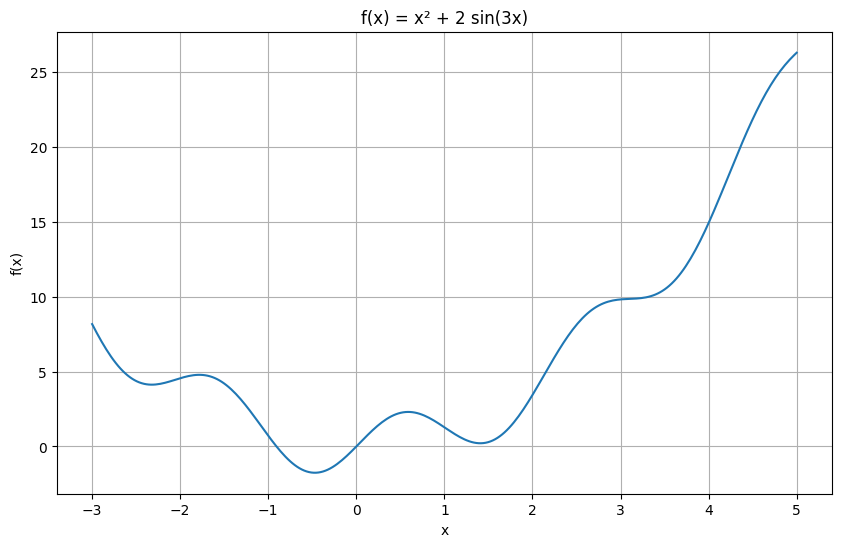

In [84]:
# Grafica de la función
lp = np.linspace(-3, 5, 300)

plt.figure(figsize=(10, 6))
plt.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = x² + 2 sin(3x)")
plt.grid(True)
plt.show()


In [85]:
# Evaluación de métodos y generación de tablas

resultados = []

# Bisección
predicciones_biseccion = {
    "[-2, 1]": "Converge al extremo local dentro del intervalo",
    "[-1, 0]": "Converge al extremo local dentro del intervalo",
    "[1, 2]": "Converge al extremo local dentro del intervalo",
}

for intervalo, prediccion in predicciones_biseccion.items():
    a, b = eval(intervalo)
    res, it, _ = biseccion(f, a, b)
    resultados.append({
        "metodo": "Bisección",
        "condicion_inicial": intervalo,
        "prediccion": prediccion,
        "resultado": round(res, 6),
        "iteraciones": it,
        "learning_rate": None,
    })

# Newton
predicciones_newton = {
    -2: "Converge al punto crítico cercano a x0",
    -1: "Converge al punto crítico cercano a x0",
    4: "Converge al punto crítico cercano a x0",
}

for x0, prediccion in predicciones_newton.items():
    res, it, _ = newton(f, x0)
    if it == 1000:
        prediccion = "No alcanzó la tolerancia en max_iter"

    resultados.append({
        "metodo": "Newton",
        "condicion_inicial": f"x0 = {x0}",
        "prediccion": prediccion,
        "resultado": round(res, 6),
        "iteraciones": it,
        "learning_rate": None,
    })

# Descenso por gradiente
predicciones_gradiente = {
    -3: "Depende del learning rate",
    0.585: "Depende del learning rate",
    4: "Depende del learning rate",
}

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]

for x0, prediccion in predicciones_gradiente.items():
    for lr in learning_rates:
        pred = prediccion
        if lr >= 0.1:
            pred = "Puede oscilar si el learning rate es grande"

        res, it, _ = descenso_gradiente(f, x0, lr=lr)
        if it == 1000:
            pred = pred + ". No alcanzó la tolerancia en max_iter"

        resultados.append({
            "metodo": "Descenso por gradiente",
            "condicion_inicial": f"x0 = {x0}",
            "prediccion": pred,
            "resultado": round(res, 6),
            "iteraciones": it,
            "learning_rate": lr,
        })

df_resultados = pd.DataFrame(resultados)
df_resultados

,metodo,condicion_inicial,prediccion,resultado,iteraciones,learning_rate
0,Bisección,"[-2, 1]",Converge al extremo local dentro del intervalo,-1.782932,23,NaN
1,Bisección,"[-1, 0]",Converge al extremo local dentro del intervalo,-0.471043,21,NaN
2,Bisección,"[1, 2]",Converge al extremo local dentro del intervalo,1.407957,21,NaN
3,Newton,x0 = -2,Converge al punto crítico cercano a x0,-1.782932,5,NaN
4,Newton,x0 = -1,Converge al punto crítico cercano a x0,0.589531,5,NaN
5,Newton,x0 = 4,No alcanzó la tolerancia en max_iter,7.820892,1000,NaN
6,Descenso por gradiente,x0 = -3,Depende del learning rate,-2.322881,636,0.001
7,Descenso por gradiente,x0 = -3,Depende del learning rate,-2.322821,148,0.005
8,Descenso por gradiente,x0 = -3,Depende del learning rate,-2.322813,77,0.010
9,Descenso por gradiente,x0 = -3,Depende del learning rate,-2.322808,12,0.050


# BONUS: Recorrido de optimización

Los métodos devuelven además un historial con todas las aproximaciones visitadas.
A continuación se grafican algunos recorridos representativos sobre la curva de f(x).

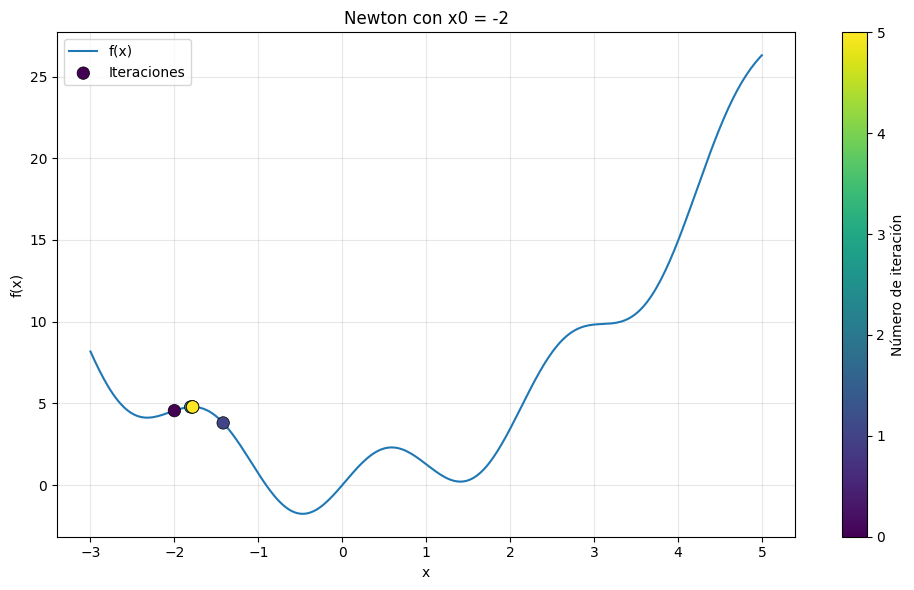

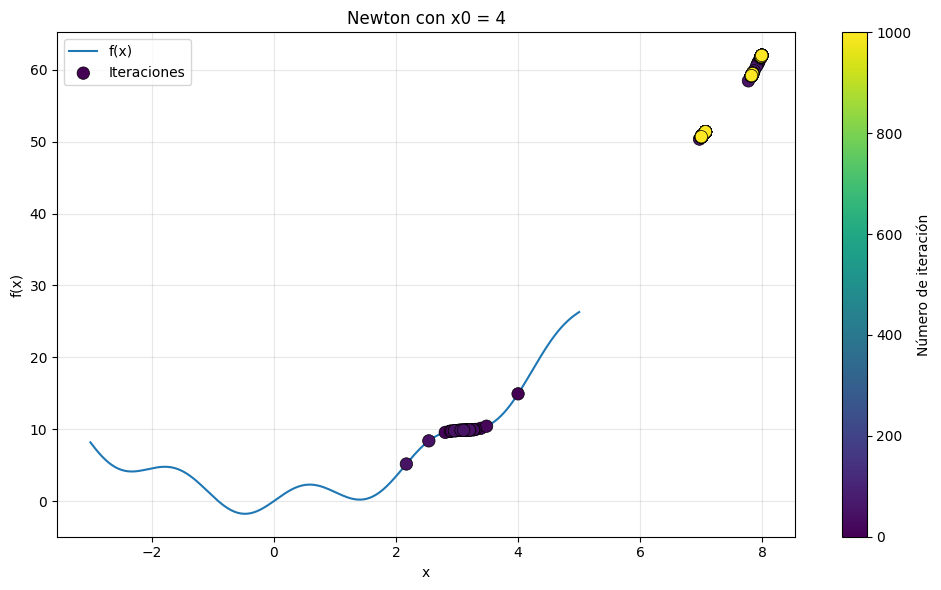

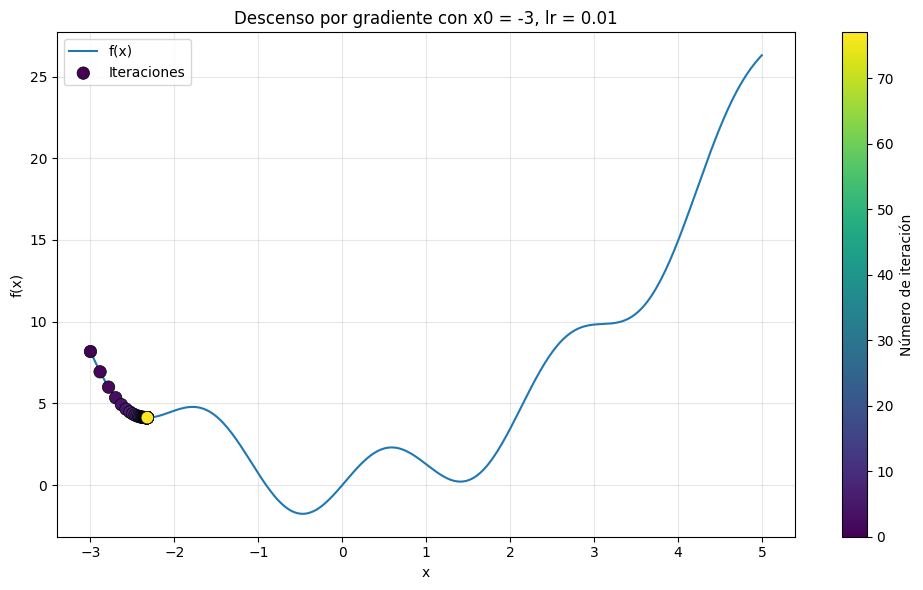

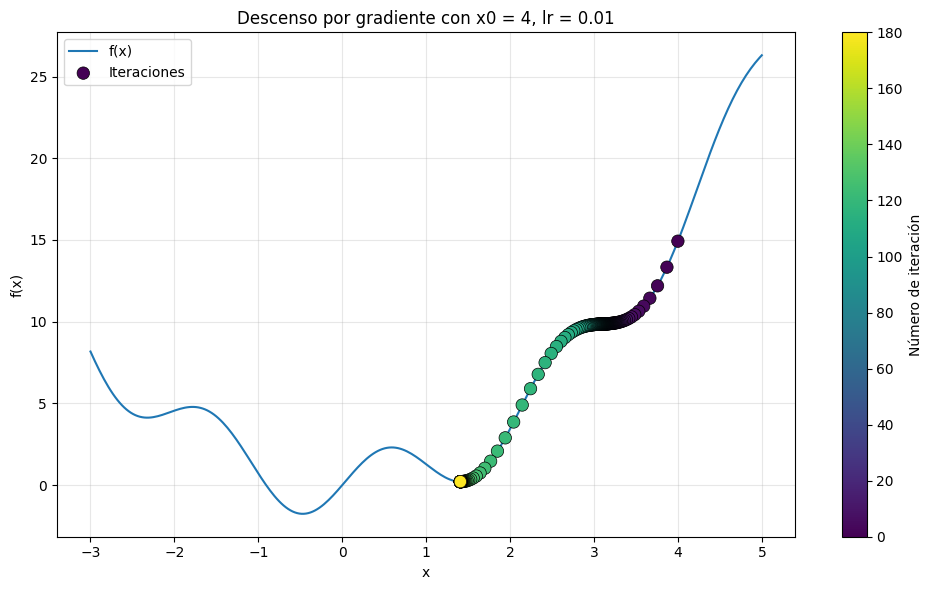

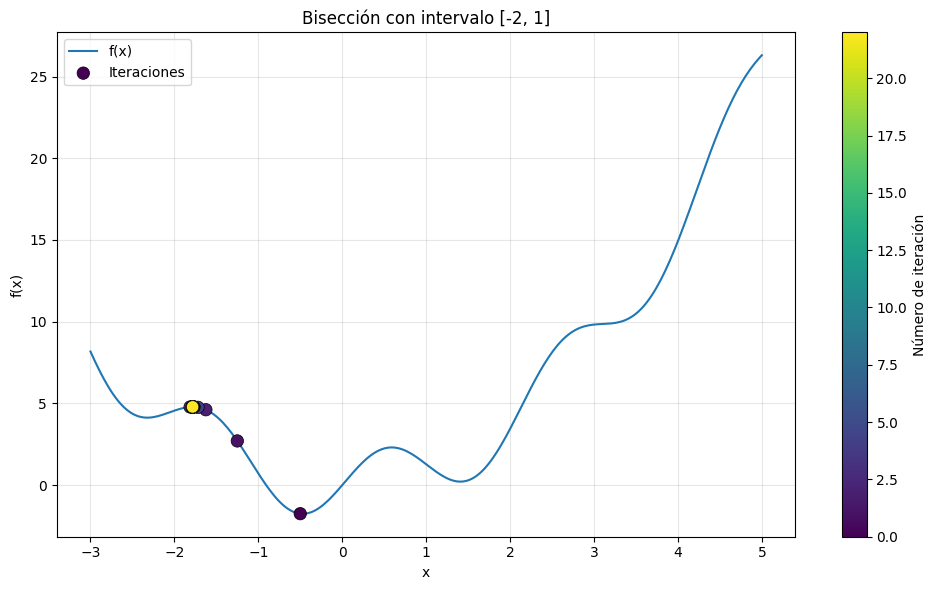

In [86]:
# Recorridos representativos

_, _, history_newton_m2 = newton(f, x0=-2)
graficar_recorrido(f, history_newton_m2, "Newton con x0 = -2")

_, _, history_newton_4 = newton(f, x0=4)
graficar_recorrido(f, history_newton_4, "Newton con x0 = 4")

_, _, history_gd_m3 = descenso_gradiente(f, x0=-3, lr=0.01)
graficar_recorrido(f, history_gd_m3, "Descenso por gradiente con x0 = -3, lr = 0.01")

_, _, history_gd_4 = descenso_gradiente(f, x0=4, lr=0.01)
graficar_recorrido(f, history_gd_4, "Descenso por gradiente con x0 = 4, lr = 0.01")

_, _, history_bis = biseccion(f, a=-2, b=1)
graficar_recorrido(f, history_bis, "Bisección con intervalo [-2, 1]")

# Ajuste de datos

In [87]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

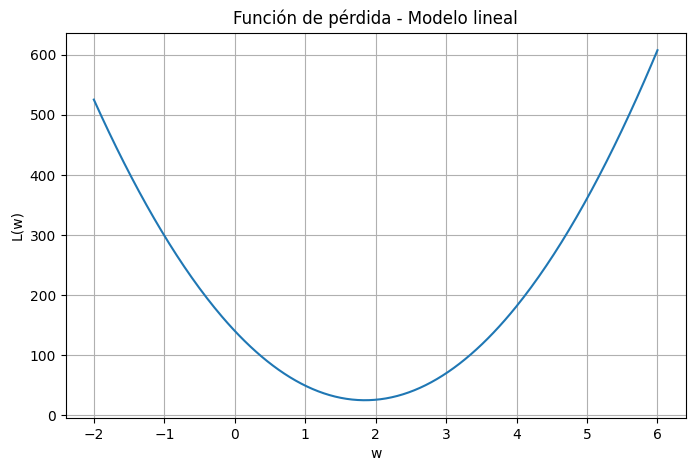

In [88]:
# Modelo lineal

def perdida_lineal(df):
    """Calcula la pérdida cuadrática media para el modelo lineal.

    Recorre los datos del dataframe y acumula el error cuadrático entre
    las predicciones lineales y los valores reales.
    """
    L = 0

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]

        # Predicción lineal y error cuadrático
        y_hat = w * xi
        error = y_hat - yi
        L = L + error**2

    return L / len(df)


L_lineal = perdida_lineal(df_linear)
valores_w = np.linspace(-2, 6, 300)
valores_L = np.array([L_lineal.eval(v) for v in valores_w])

# Gráfica de la función de pérdida para el modelo lineal
plt.figure(figsize=(8, 5))
plt.plot(valores_w, valores_L)
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo lineal")
plt.grid(True)
plt.show()



In [89]:
# Optimice la función de pérdida para el modelo lineal
w_opt, iteraciones, _ = descenso_gradiente(L_lineal, x0=0, lr=0.01)

print("w óptimo:", w_opt)
print("Iteraciones:", iteraciones)
print("Pérdida mínima aproximada:", L_lineal.eval(w_opt))

w óptimo: 1.8479933639545483
Iteraciones: 14
Pérdida mínima aproximada: 25.242043776120045


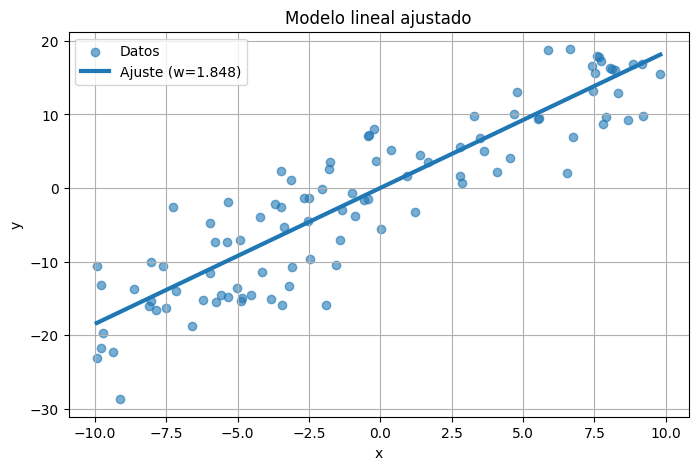

In [90]:
# Grafique datos y ajuste para el modelo lineal
plt.figure(figsize=(8, 5))

# Datos originales
plt.scatter(df_linear["x"], df_linear["y"], alpha=0.6, label="Datos")

# Modelo ajustado
x_plot = np.linspace(
    df_linear["x"].min(),
    df_linear["x"].max(),
    200
)

y_plot = w_opt * x_plot

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo lineal ajustado")
plt.legend()
plt.grid(True)

plt.show()

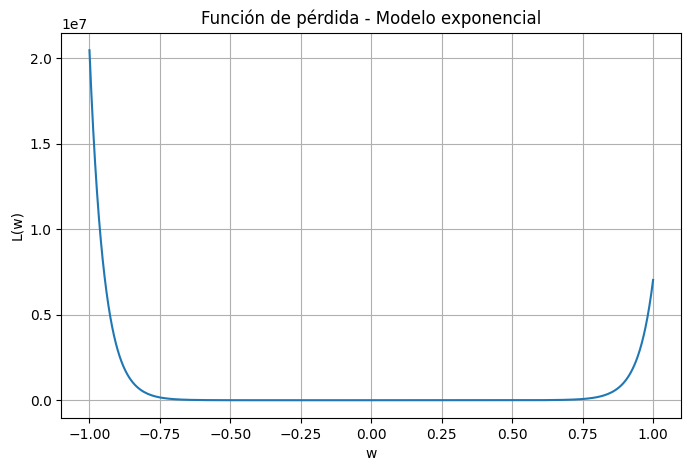

In [91]:
# Modelo exponencial

def perdida_exponencial(df):
    """Calcula la pérdida cuadrática media para el modelo exponencial.

    Para cada dato, evalúa exp(w * x) y acumula el error cuadrático.
    """
    L = 0

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]

        # Predicción exponencial y error cuadrático
        y_hat = exp(w * xi)
        error = y_hat - yi
        L = L + error**2

    return L / len(df)


L_exp = perdida_exponencial(df_exp)

# Gráfica de la función de pérdida para el modelo exponencial
valores_w = np.linspace(-1, 1, 300)
valores_L = np.array([L_exp.eval(v) for v in valores_w])

plt.figure(figsize=(8,5))
plt.plot(valores_w, valores_L)
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo exponencial")
plt.grid(True)
plt.show()



In [92]:
# Optimice la función de pérdida para el modelo exponencial
w_opt_exp, iteraciones_exp, _ = descenso_gradiente(
    L_exp,
    x0=0,
    lr=0.001
)

print("w óptimo:", w_opt_exp)
print("Iteraciones:", iteraciones_exp)
print("Pérdida mínima:", L_exp.eval(w_opt_exp))

w óptimo: 0.21257605307354413
Iteraciones: 14
Pérdida mínima: 0.9943782645836385


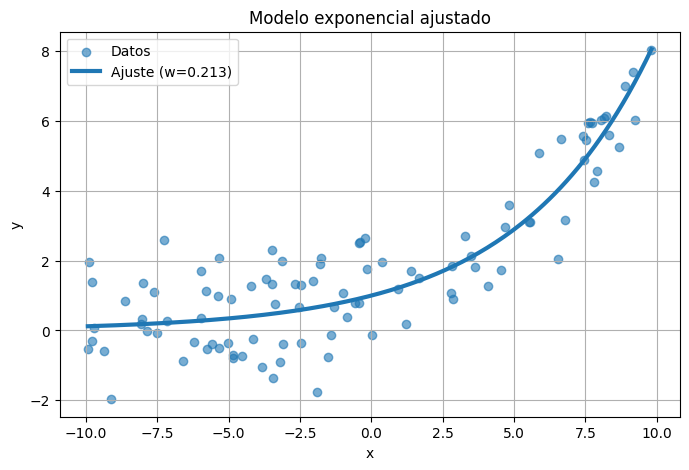

In [93]:
# Grafique datos y ajuste para el modelo exponencial

plt.figure(figsize=(8, 5))

plt.scatter(df_exp["x"], df_exp["y"], alpha=0.6, label="Datos")

x_plot = np.linspace(
    df_exp["x"].min(),
    df_exp["x"].max(),
    200
)

y_plot = np.exp(w_opt_exp * x_plot)

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt_exp:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo exponencial ajustado")
plt.legend()
plt.grid(True)

plt.show()

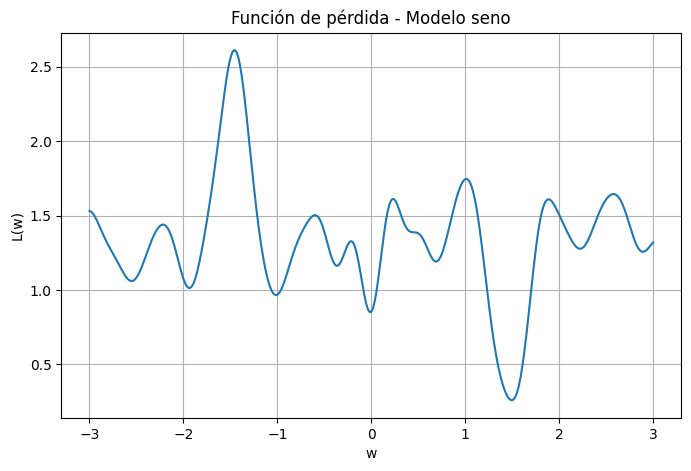

In [94]:
# Función de pérdida para el modelo seno

def perdida_seno(df):
    """Calcula la pérdida cuadrática media para el modelo seno.

    Para cada dato, evalúa sin(w * x) y acumula el error cuadrático.
    """
    L = 0

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]

        # Predicción de la función seno y error cuadrático
        y_hat = sin(w * xi)
        error = y_hat - yi
        L = L + error**2

    return L / len(df)


L_sin = perdida_seno(df_sin)

# Gráfico de la función de pérdida para el modelo seno
valores_w = np.linspace(-3, 3, 500)
valores_L = np.array([L_sin.eval(v) for v in valores_w])

plt.figure(figsize=(8,5))
plt.plot(valores_w, valores_L)
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo seno")
plt.grid(True)
plt.show()



In [70]:
# Optimización del modelo seno

w_opt_sin, iteraciones_sin, _ = descenso_gradiente(
    L_sin,
    x0=1.5,
    lr=0.01
)

print("w óptimo:", w_opt_sin)
print("Iteraciones:", iteraciones_sin)
print("Pérdida mínima:", L_sin.eval(w_opt_sin))

w óptimo: 1.4949827245063096
Iteraciones: 23
Pérdida mínima: 0.25985981910251416


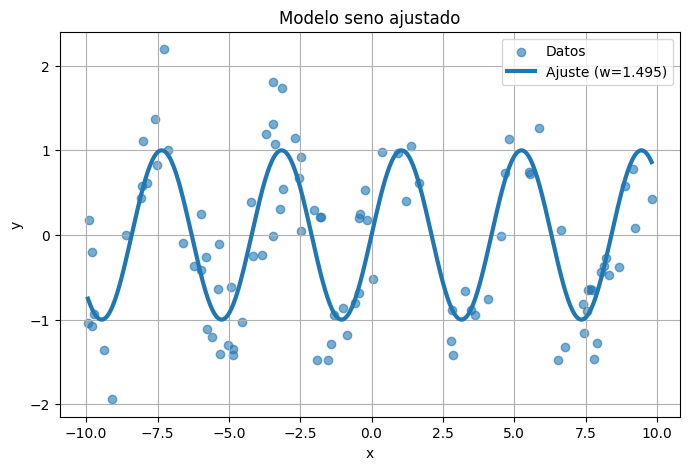

In [95]:
# Grafique datos y ajuste para el modelo seno

plt.figure(figsize=(8, 5))

plt.scatter(df_sin["x"], df_sin["y"], alpha=0.6, label="Datos")

x_plot = np.linspace(
    df_sin["x"].min(),
    df_sin["x"].max(),
    500
)

y_plot = np.sin(w_opt_sin * x_plot)

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt_sin:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo seno ajustado")
plt.legend()
plt.grid(True)

plt.show()

# Parte 5 - BONUS

En esta parte se agregan variantes del descenso por gradiente y una formulación alternativa para el ajuste lineal.

## 5.1 Descenso por gradiente estocástico (SGD)

In [96]:
# Descenso por gradiente estocástico para los modelos de ajuste

def predecir_modelo(modelo, w_val, x_val):
    """Genera la predicción del modelo especificado para un solo dato."""
    if modelo == "lineal":
        return w_val * x_val
    if modelo == "exponencial":
        return np.exp(w_val * x_val)
    if modelo == "seno":
        return np.sin(w_val * x_val)

    raise ValueError("Modelo no reconocido")


def perdida_modelo(modelo, df, w_val):
    """Calcula la pérdida media para el modelo dado sobre el dataframe."""
    errores = []

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]
        y_hat = predecir_modelo(modelo, w_val, xi)
        errores.append((y_hat - yi)**2)

    return np.mean(errores)


def gradiente_dato(modelo, w_val, xi, yi):
    """Calcula el gradiente de la pérdida al usar un solo dato."""
    if modelo == "lineal":
        return 2 * (w_val * xi - yi) * xi

    if modelo == "exponencial":
        y_hat = np.exp(w_val * xi)
        return 2 * (y_hat - yi) * y_hat * xi

    if modelo == "seno":
        y_hat = np.sin(w_val * xi)
        return 2 * (y_hat - yi) * np.cos(w_val * xi) * xi

    raise ValueError("Modelo no reconocido")


def sgd(modelo, df, w0, lr=0.01, max_iter=1000, tol=1e-6, seed=42):
    """Aplica SGD para optimizar el parámetro w sobre un dataset.

    En cada iteración selecciona un dato al azar y actualiza el parámetro con
    el gradiente calculado para ese solo punto.
    """
    rng = np.random.default_rng(seed)
    w_actual = w0
    history = [w_actual]

    for step in range(1, max_iter + 1):
        i = rng.integers(0, len(df))
        xi = df.iloc[i]["x"]
        yi = df.iloc[i]["y"]

        gradiente = gradiente_dato(modelo, w_actual, xi, yi)
        w_next = w_actual - lr * gradiente

        # Protección contra valores no finitos
        if not np.isfinite(w_next):
            return w_actual, step, history

        if abs(w_next - w_actual) < tol:
            history.append(w_next)
            return w_next, step, history

        w_actual = w_next
        history.append(w_actual)

    return w_actual, max_iter, history



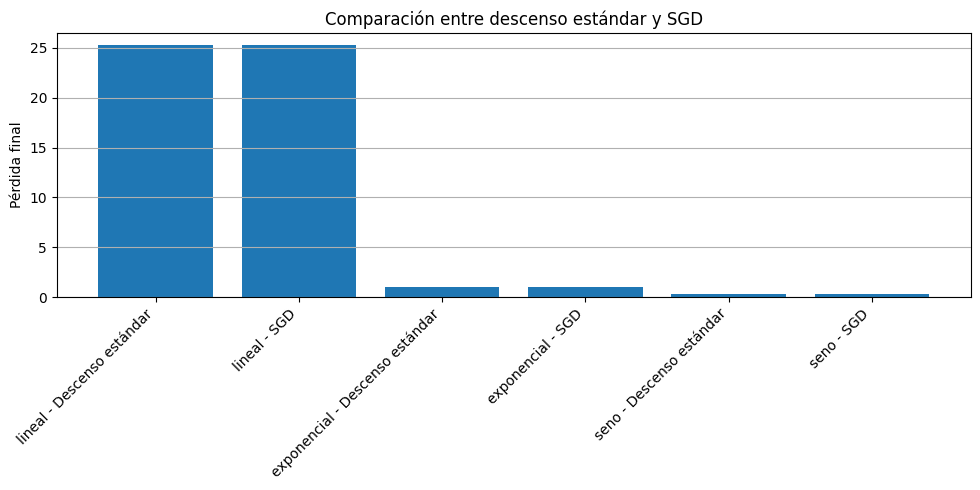

In [106]:
# Comparación de pérdidas finales
df_sgd = pd.DataFrame([
    {
        "modelo": "lineal",
        "metodo": "Descenso estándar",
        "w_obtenido": 1.847993,
        "iteraciones": 14,
        "perdida_final": 25.242044,
    },
    {
        "modelo": "lineal",
        "metodo": "SGD",
        "w_obtenido": 1.848261,
        "iteraciones": 20000,
        "perdida_final": 25.242046,
    },
    {
        "modelo": "exponencial",
        "metodo": "Descenso estándar",
        "w_obtenido": 0.212576,
        "iteraciones": 14,
        "perdida_final": 0.994378,
    },
    {
        "modelo": "exponencial",
        "metodo": "SGD",
        "w_obtenido": 0.211674,
        "iteraciones": 20000,
        "perdida_final": 0.994751,
    },
    {
        "modelo": "seno",
        "metodo": "Descenso estándar",
        "w_obtenido": 1.494983,
        "iteraciones": 23,
        "perdida_final": 0.259860,
    },
    {
        "modelo": "seno",
        "metodo": "SGD",
        "w_obtenido": 1.476336,
        "iteraciones": 20000,
        "perdida_final": 0.264583,
    },
])

df_sgd
labels = df_sgd["modelo"] + " - " + df_sgd["metodo"]

plt.figure(figsize=(10, 5))
plt.bar(labels, df_sgd["perdida_final"])
plt.ylabel("Pérdida final")
plt.title("Comparación entre descenso estándar y SGD")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


SGD usa solo un dato por iteración, por lo que cada actualización es menos costosa. En estos experimentos llega a valores cercanos a los del descenso estándar, aunque necesita muchas más iteraciones y su resultado depende del orden aleatorio de los datos. Para el modelo exponencial fue necesario usar un learning rate más chico para evitar inestabilidad numérica.

## 5.2 Descenso por gradiente con learning rate variable

In [98]:
# Descenso por gradiente con learning rate variable

def descenso_gradiente_lr_variable(f: Function, x0: float, lr0: float = 0.1, decay: float = 0.05, tol: float = 1e-6, max_iter: int = 1000) -> tuple:
    """Descenso por gradiente con learning rate que decae con las iteraciones."""
    df = f.derivative()

    xn = x0
    history = [xn]

    for step in range(1, max_iter + 1):
        lr_t = lr0 / (1 + decay * step)
        gradiente = df.eval(xn)
        x_next = xn - lr_t * gradiente

        # Criterio de parada con learning rate variable
        if abs(x_next - xn) < tol:
            history.append(x_next)
            return x_next, step, history

        xn = x_next
        history.append(xn)

    return xn, max_iter, history



In [107]:
# Recorridos de las aproximaciones para learning rate clásico y variable
plt.figure(figsize=(10, 5))

for (x0, metodo), history in historias_lr.items():
    plt.plot(history, label=f"x0 = {x0}, {metodo}")

plt.xlabel("Iteración")
plt.ylabel("x")
plt.title("Recorridos con learning rate clásico y variable")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'historias_lr' is not defined

<Figure size 1000x500 with 0 Axes>

El learning rate variable permite empezar con pasos grandes y luego reducirlos progresivamente. Esto suele mejorar la estabilidad cerca del punto crítico, porque las actualizaciones finales son más pequeñas. En estos casos mantiene resultados similares al descenso clásico y puede ayudar a reducir oscilaciones cuando el learning rate inicial es relativamente grande.

## 5.3 Formulación producto de exponenciales vs suma

In [100]:
# Formulación alternativa para el modelo lineal

x_lineal = df_linear["x"].to_numpy()
y_lineal = df_linear["y"].to_numpy()


def errores_lineal(w_val):
    """Calcula el vector de errores para el modelo lineal alternativo."""
    return w_val * x_lineal - y_lineal


def L_tilde(w_val):
    """Define la función L_tilde como el producto de exponenciales de errores."""
    errores = errores_lineal(w_val)

    with np.errstate(under="ignore"):
        return np.prod(np.exp(-(errores**2)))


def log_L_tilde(w_val):
    """Calcula el logaritmo negativo de L_tilde para evitar subdesbordamiento."""
    errores = errores_lineal(w_val)
    return -np.sum(errores**2)


def gradiente_L_tilde(w_val):
    """Calcula el gradiente de L_tilde usando derivadas analíticas."""
    errores = errores_lineal(w_val)
    grad_log = -2 * np.sum(errores * x_lineal)
    return L_tilde(w_val) * grad_log


def gradiente_menos_log_L_tilde(w_val):
    """Calcula el gradiente de la formulación -log(L_tilde)."""
    errores = errores_lineal(w_val)
    return 2 * np.sum(errores * x_lineal)


def descenso_menos_L_tilde(w0, lr=1e-5, tol=1e-12, max_iter=1000):
    """Optimiza la formulación con L_tilde usando gradiente ascendente."""
    w_actual = w0
    history = [w_actual]

    for step in range(1, max_iter + 1):
        gradiente = gradiente_L_tilde(w_actual)
        # Minimizar -L_tilde equivale a maximizar L_tilde.
        w_next = w_actual + lr * gradiente

        if abs(w_next - w_actual) < tol:
            history.append(w_next)
            return w_next, step, history

        w_actual = w_next
        history.append(w_actual)

    return w_actual, max_iter, history


def descenso_menos_log_L_tilde(w0, lr=0.0001, tol=1e-6, max_iter=1000):
    """Optimiza la formulación -log(L_tilde) usando gradiente descendente."""
    w_actual = w0
    history = [w_actual]

    for step in range(1, max_iter + 1):
        gradiente = gradiente_menos_log_L_tilde(w_actual)
        w_next = w_actual - lr * gradiente

        if abs(w_next - w_actual) < tol:
            history.append(w_next)
            return w_next, step, history

        w_actual = w_next
        history.append(w_actual)

    return w_actual, max_iter, history



In [102]:
# Comparación de magnitud de gradientes
magnitudes_gradientes = pd.DataFrame([
    {
        "formulacion": "L(w) estándar",
        "gradiente_en_w0": abs(L_lineal.derivative().eval(0)),
        "gradiente_en_optimo": abs(L_lineal.derivative().eval(w_opt)),
    },
    {
        "formulacion": "Producto L_tilde(w)",
        "gradiente_en_w0": abs(gradiente_L_tilde(0)),
        "gradiente_en_optimo": abs(gradiente_L_tilde(w_opt)),
    },
    {
        "formulacion": "-log(L_tilde(w))",
        "gradiente_en_w0": abs(gradiente_menos_log_L_tilde(0)),
        "gradiente_en_optimo": abs(gradiente_menos_log_L_tilde(w_opt)),
    },
])

magnitudes_gradientes


,formulacion,gradiente_en_w0,gradiente_en_optimo
0,L(w) estándar,124.814640,0.000018
1,Producto L_tilde(w),0.000000,0.000000
2,-log(L_tilde(w)),12481.464004,0.001799


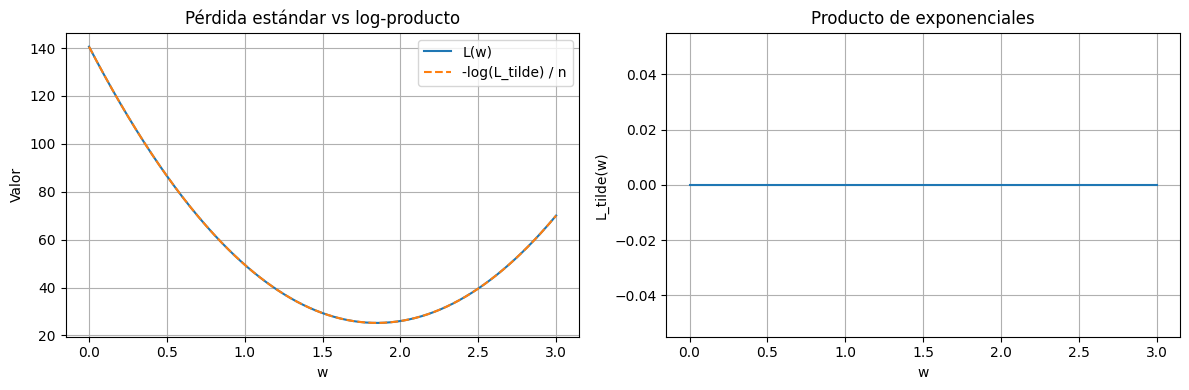

In [103]:
# Comparación visual de las formulaciones
valores_w = np.linspace(0, 3, 300)
valores_L = np.array([L_lineal.eval(v) for v in valores_w])
valores_menos_log_promedio = np.array([-log_L_tilde(v) / len(df_linear) for v in valores_w])
valores_producto = np.array([L_tilde(v) for v in valores_w])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(valores_w, valores_L, label="L(w)")
axes[0].plot(valores_w, valores_menos_log_promedio, linestyle="--", label="-log(L_tilde) / n")
axes[0].set_xlabel("w")
axes[0].set_ylabel("Valor")
axes[0].set_title("Pérdida estándar vs log-producto")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(valores_w, valores_producto)
axes[1].set_xlabel("w")
axes[1].set_ylabel("L_tilde(w)")
axes[1].set_title("Producto de exponenciales")
axes[1].grid(True)

plt.tight_layout()
plt.show()
